In [1]:
import sympy as smp
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

In [2]:
t, m, R, g, a, lm1, lm2, om = smp.symbols(r"t m R g a \lambda_1 \lambda_2 \omega", real=True)
r, the, phi = smp.symbols(r"r \theta \phi", cls=smp.Function)
r = r(t)
the = the(t)
phi = phi(t)

def dt(x):
    return smp.diff(x), smp.diff(smp.diff(x))

r_d, r_dd = dt(r)
the_d, the_dd = dt(the)
phi_d, phi_dd = dt(phi)

In [3]:
v = smp.Matrix([r_d, r*the_d])

In [4]:
I = m * (r * smp.cos(the))**2
T = 1/2 * m * v.dot(v) + 1/2 * I * om**2
U = m * g * r * smp.cos(the)
L = T - U
L

0.5*\omega**2*m*r(t)**2*cos(\theta(t))**2 - g*m*r(t)*cos(\theta(t)) + 0.5*m*(r(t)**2*Derivative(\theta(t), t)**2 + Derivative(r(t), t)**2)

In [5]:
def lagrange_eq(L, variables, R=0):
    lagrange_equations = []

    for q in variables:
        q_dot = smp.diff(q, t)
        LE = smp.diff(smp.diff(L, q_dot), t) - smp.diff(L, q) + smp.diff(R, q_dot)
        LE = LE.simplify()
        lagrange_equations.append(LE)
        
    return tuple(lagrange_equations)

In [6]:
LEr, LEthe = lagrange_eq(L, (r, the))

In [7]:
LEr

1.0*m*(-\omega**2*r(t)*cos(\theta(t))**2 + g*cos(\theta(t)) - r(t)*Derivative(\theta(t), t)**2 + Derivative(r(t), (t, 2)))

In [8]:
LEthe

m*(0.5*\omega**2*r(t)*sin(2*\theta(t)) - g*sin(\theta(t)) + 1.0*r(t)*Derivative(\theta(t), (t, 2)) + 2.0*Derivative(\theta(t), t)*Derivative(r(t), t))*r(t)

# Constraints

The constraint the disc stays anchored to the hoop. So the position $r$ is always equal to the sum of the two radiuses $R + l$.

$$ r = a $$
$$ r - a = 0 $$

In [9]:
system = smp.Matrix(
    [
        LEr + lm1,
        LEthe,
    ]
)
system

Matrix([
[                     \lambda_1 + 1.0*m*(-\omega**2*r(t)*cos(\theta(t))**2 + g*cos(\theta(t)) - r(t)*Derivative(\theta(t), t)**2 + Derivative(r(t), (t, 2)))],
[m*(0.5*\omega**2*r(t)*sin(2*\theta(t)) - g*sin(\theta(t)) + 1.0*r(t)*Derivative(\theta(t), (t, 2)) + 2.0*Derivative(\theta(t), t)*Derivative(r(t), t))*r(t)]])

Substitue the constraints

In [10]:
system = system.subs({r: a, r_d: 0, r_dd: 0, phi_dd: the_dd})
system

Matrix([
[\lambda_1 + 1.0*m*(-\omega**2*a*cos(\theta(t))**2 - a*Derivative(\theta(t), t)**2 + g*cos(\theta(t)))],
[      a*m*(0.5*\omega**2*a*sin(2*\theta(t)) + 1.0*a*Derivative(\theta(t), (t, 2)) - g*sin(\theta(t)))]])

In [11]:
the_dd_eq = smp.solve(system[1], the_dd)[0]
smp.Eq(the_dd, the_dd_eq).expand()

Eq(Derivative(\theta(t), (t, 2)), -\omega**2*sin(\theta(t))*cos(\theta(t)) + g*sin(\theta(t))/a)

We obtain that

$$ \ddot{\theta} = - \omega^2 \sin(\theta)\cos(\theta) + \frac{g}{a} \sin(\theta)$$

We can use the chain rule $\ddot{\theta} = \frac{d\dot{\theta}}{d\theta} \frac{d\theta}{dt} = \dot{\theta} \frac{d\dot{\theta}}{d\theta}$

$$ \int \dot{\theta} ~ d\dot{\theta} = \int \dots ~ d\theta $$

$$ \frac{1}{2}\dot{\theta}^2 = \dots + c $$

Solve for $c$, such that the intial conditions are $\theta = \dot{\theta} = 0$

In [12]:
the_d2 = smp.integrate(the_dd_eq.expand(), the)
# Comes from the other side
the_d2 = 2 * the_d2
the_d2

-\omega**2*sin(\theta(t))**2 - 2*g*cos(\theta(t))/a

In [13]:
c = the_d2.subs({the: 0})
c

-2*g/a

We can substitute $\dot{\theta}^2$ inside the $r$ equation.

In [14]:
lm1_eq = system[0].subs({the_d**2: the_d2 + c}).simplify()
lm1_eq

\lambda_1 + 1.0*m*(-2*\omega**2*a*cos(\theta(t))**2 + \omega**2*a + 3*g*cos(\theta(t)) + 2*g)

In [15]:
lm1_eq = smp.solve(lm1_eq, lm1)[0]
smp.Eq(lm1, lm1_eq)

Eq(\lambda_1, m*(-2.0*\omega**2*a*sin(\theta(t))**2 + \omega**2*a - 3.0*g*cos(\theta(t)) - 2.0*g))

In [16]:
om_eq = smp.solve(lm1_eq, om)[1]
om_eq

sqrt(g*(3.0*cos(\theta(t)) + 2.0)/(a*cos(2.0*\theta(t))))

Now we need to check that quantity under the square root is greater than zero in order to have a stationary point

In [17]:
# smp.solve(om_eq, the)[1]

# Solving the equation of motion

In [18]:
om_f = smp.lambdify((a, g, the,), om_eq)
# om0_f = smp.lambdify((a, g), smp.solve(om_eq, the)[1])

In [19]:
dthedt_f = smp.lambdify(the_d, the_d)
ddtheddt_f = smp.lambdify((a, g, om, the, the_d), the_dd_eq)

In [20]:
def dSdt(S, t, a, g, om):
    the, the_d = S
    return [
        dthedt_f(the_d),
        ddtheddt_f(a, g, om, the, the_d),
    ]

In [21]:
t = np.linspace(0, 10, 1000)
a = 2
g = 9.8
om = 1

In [22]:
s = odeint(dSdt, y0=[1, 2], t=t, args=(a, g, 1))

In [23]:
the_t = s.T[0]

z_t = a * np.cos(the_t)

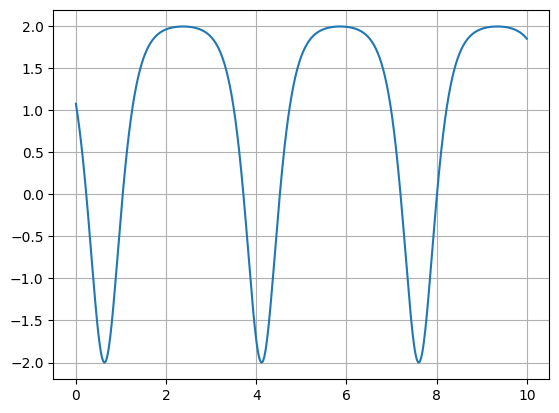

In [24]:
plt.grid()
plt.plot(t, z_t)

<lambdifygenerated-1>:2: RuntimeWarning: invalid value encountered in sqrt
  return sqrt(g*(3.0*cos(_Dummy_81) + 2.0)/(a*cos(2.0*_Dummy_81)))


Text(0, 0.5, 'Stationary angular velocity $\\omega$')

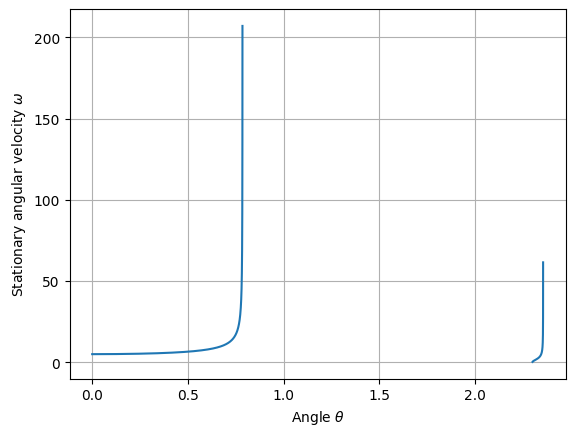

In [25]:
angle = np.linspace(0, np.pi, 10000)
omega = om_f(a, g, angle)

plt.grid()
plt.plot(angle, omega)
plt.xlabel(r"Angle $\theta$")
plt.ylabel(r"Stationary angular velocity $\omega$")
# plt.scatter(om0_f(a, g), 0, color="r")


In [26]:
om_f(a, g, 0.5)

np.float64(6.4818496542407695)